In [1]:
import time
t1 = time.time()

import math
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam , SGD , Adagrad
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, CSVLogger, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras import regularizers , initializers
from sklearn.metrics import confusion_matrix
import tensorflow.keras.backend as K
from sklearn import metrics
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

gpus = tf.config.experimental.list_physical_devices("GPU")
tf.config.set_visible_devices(gpus[1], "GPU")

### set seed ###
keras.utils.set_random_seed(2330)
tf.config.experimental.enable_op_determinism()

2026-03-18 04:07:12.730851: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
##### load data #####

HLdata_path = "/root/data/mucollider/two_boosted/test_HLfeature.h5"
HLdata_file = h5py.File(HLdata_path, 'r')
print(HLdata_file.keys())

LLdata_path = "/root/data/mucollider/two_boosted/test_LLfeature.h5"
LLdata_file = h5py.File(LLdata_path, 'r')
print(LLdata_file.keys())

<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_everytype', 'target_sigbg']>
<KeysViewHDF5 ['particle_info']>


In [3]:
##### include data #####

HLfeatures = ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading']
LLfeatures = ['particle_info']

##### select BTag work point at WP70 (BitNumber 1) #####

BTag_leading = ((HLdata_file['BTag_leading'][:])&2)
BTag_subleading = ((HLdata_file['BTag_subleading'][:])&2)

##### include other high level features data #####

HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': HLdata.append(BTag_leading)
    elif feature=='BTag_subleading': HLdata.append(BTag_subleading)
    else: HLdata.append(HLdata_file[feature][:])
HLdata = np.array(HLdata).T
print('shape of high level data:', HLdata.shape)

LLdata = LLdata_file['particle_info'][:]
print('shape of low level data:', LLdata.shape)

target = HLdata_file['target_sigbg'][:]
print('shape of target:', target.shape)

shape of high level data: (347538, 16)
shape of low level data: (347538, 160)
shape of target: (347538,)


In [4]:
##### load the model #####

model = models.load_model("/root/data/mucollider/two_boosted/model_mucollider_v2.h5")

2026-03-18 04:07:16.998500: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46696 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:25:00.0, compute capability: 8.6


In [5]:
### model test ###

HLtest = []
LLtest = []
targettest = []
prediction = []

BR_hbb = 0.5824
processes = ["hhvv", "hhmumu", "jjBG_ptcut", "ttBG_ptcut", "bbBG_ptcut", "wwBG", "wwvvBG", "zzBG", "zzvvBG", "hzvvBG"]
event_num = [59247, 57847, 14119, 14298, 15633, 20285, 40078, 24300, 48454, 53277]
Xsection = [5.6572451e-02*BR_hbb*BR_hbb, 4.758146e-03*BR_hbb*BR_hbb, 1.345440e+01, 4.423700e+00, 2.325600e+00, 1.507183e+02, 1.223107e+01, 9.617100e+00, 6.469436e+00, 1.27619546e+00*BR_hbb]     ### unit: fb
simulation_num = 200000
Luminosity = 1000   ### unit: fb^-1

count = 0
for process in processes:
    HLtest.append(HLdata[count:count+event_num[processes.index(process)]])
    LLtest.append(LLdata[count:count+event_num[processes.index(process)]])
    targettest.append(target[count:count+event_num[processes.index(process)]])
    prediction.append(model.predict([HLtest[-1], LLtest[-1]]))
    count += event_num[processes.index(process)]

  89/1852 [>.............................] - ETA: 3s

2026-03-18 04:07:18.954388: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


1665/1665 [==============================] - 3s 2ms/step


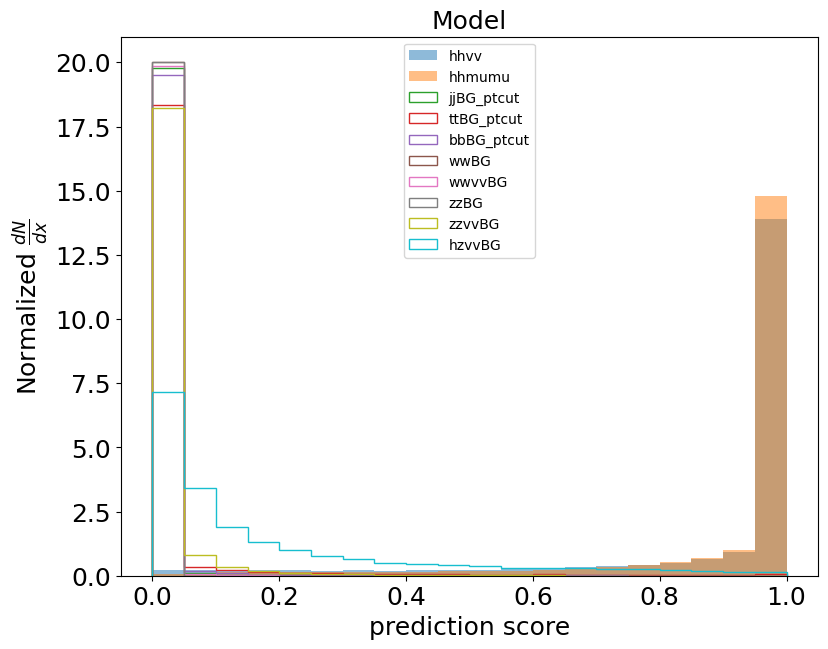

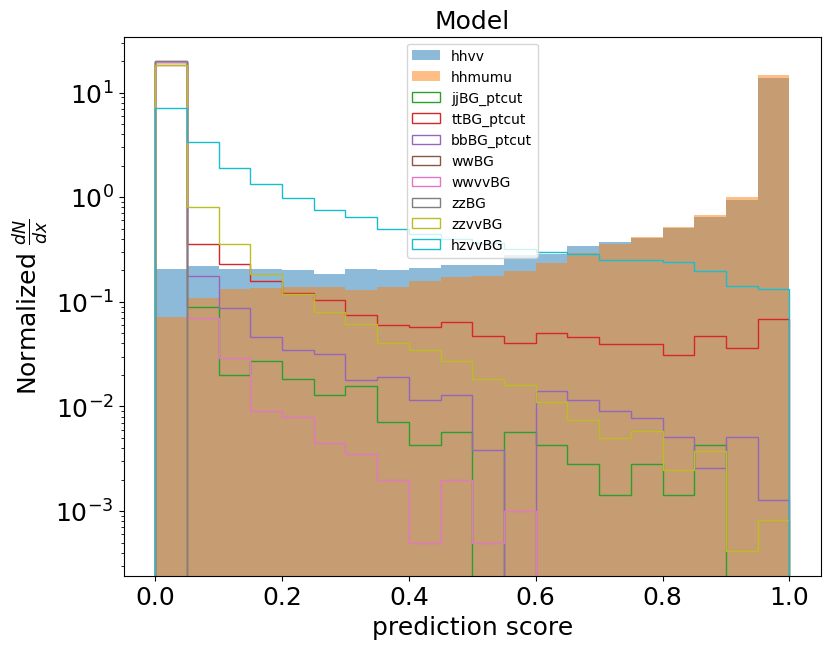

In [6]:
##### plot the prediction histogram #####

plt.figure(1, figsize=(9,7))
bins = np.linspace(0,1,21)
for process in processes:
    plt.hist(prediction[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"prediction score", fontsize=18)
plt.ylabel(r"Normalized $\frac{dN}{dx}$", fontsize=18)
# plt.yscale("log")
plt.title("Model", fontsize=18)
plt.legend(loc='best')
plt.show()

plt.figure(1, figsize=(9,7))
bins = np.linspace(0,1,21)
for process in processes:
    plt.hist(prediction[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"prediction score", fontsize=18)
plt.ylabel(r"Normalized $\frac{dN}{dx}$", fontsize=18)
plt.yscale("log")
plt.title("Model", fontsize=18)
plt.legend(loc='best')
plt.show()

In [7]:
### Do the score cut ###

score_cuts = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 0.999]

for score_cut in score_cuts:
    print("In score cut", score_cut)

    num_afterML = []
    for process in processes: num_afterML.append(sum(prediction[processes.index(process)]>=score_cut)[0])
    print("Number before ML: ", event_num)
    print("Number after  ML: ", num_afterML)
    
    ### calculate significance ###
    
    s, b = 0, 0
    for process in processes[0:2]:
        s += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
    for process in processes[2:]:
        b += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
        
    def significance(s,b):
        return np.sqrt(2*((s+b)*np.log(1+s/b)-s))
    
    z = significance(s,b)
    print("signal events:", s)
    print("background events:", b)
    print("significance:", z)
    print("\n")

In score cut 0.5
Number before ML:  [59247, 57847, 14119, 14298, 15633, 20285, 40078, 24300, 48454, 53277]
Number after  ML:  [53084, 54015, 16, 319, 47, 0, 3, 0, 172, 6623]
signal events: 5.528968186359357
background events: 39.038780761960965
significance: 0.8651597924129789


In score cut 0.7
Number before ML:  [59247, 57847, 14119, 14298, 15633, 20285, 40078, 24300, 48454, 53277]
Number after  ML:  [49743, 51417, 7, 187, 24, 0, 0, 0, 44, 3233]
signal events: 5.187454599834824
background events: 18.32414847338816
significance: 1.1605025254789438


In score cut 0.8
Number before ML:  [59247, 57847, 14119, 14298, 15633, 20285, 40078, 24300, 48454, 53277]
Number after  ML:  [47430, 49183, 4, 131, 11, 0, 0, 0, 18, 1894]
signal events: 4.947508749355231
background events: 10.91540529401088
significance: 1.4015622205401095


In score cut 0.9
Number before ML:  [59247, 57847, 14119, 14298, 15633, 20285, 40078, 24300, 48454, 53277]
Number after  ML:  [43988, 45703, 0, 75, 5, 0, 0, 0, 3, 725

/tmp/ipykernel_1709/3436209754.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(2*((s+b)*np.log(1+s/b)-s))


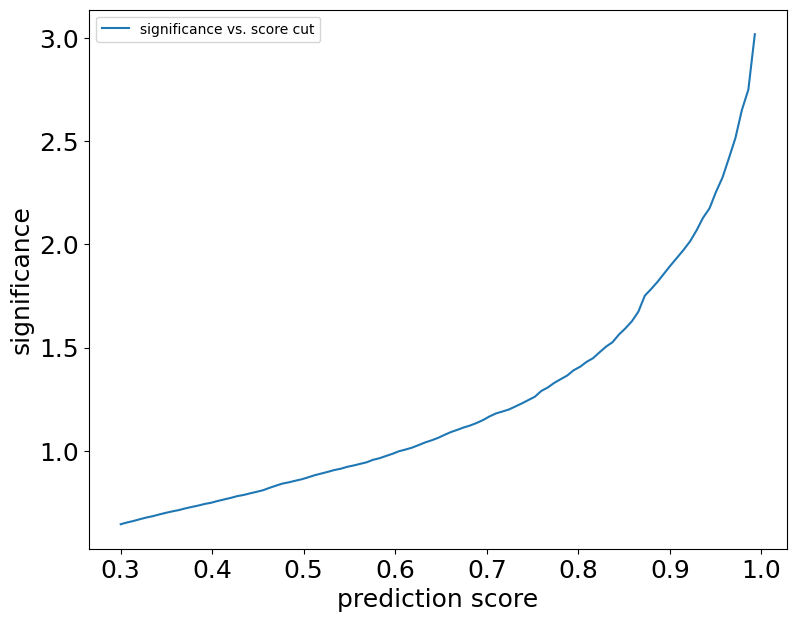

In [8]:
scores = np.linspace(0.3, 1, 100)
z_line = []

def significance(s,b):
    return np.sqrt(2*((s+b)*np.log(1+s/b)-s))

for score in scores:
    num_afterML = []
    for process in processes: num_afterML.append(sum(prediction[processes.index(process)]>=score)[0])
    s, b = 0, 0
    for process in processes[0:2]:
        s += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
    for process in processes[2:]:
        b += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
    
    z_line.append(significance(s,b))

plt.figure(1, figsize=(9,7))
plt.plot(scores, z_line, label='significance vs. score cut')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"prediction score", fontsize=18)
plt.ylabel(r"significance", fontsize=18)
plt.legend(loc='best')
plt.show()

high level influence:  0.05773576
low  level influence:  0.05361045


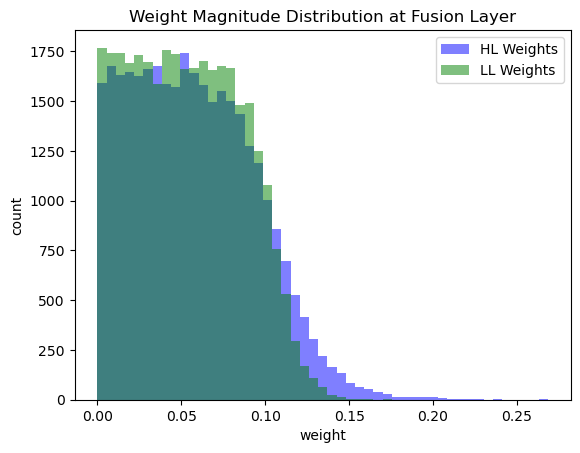

In [9]:
### check which part of model is more important ###

weights, biases = model.get_layer('dense_4').get_weights()
hl_influence = np.mean(np.abs(weights[:128, :]))
ll_influence = np.mean(np.abs(weights[128:, :]))
print("high level influence: ", hl_influence)
print("low  level influence: ", ll_influence)

weights, _ = model.get_layer('dense_4').get_weights()

hl_weights = np.abs(weights[:128, :]).flatten()
ll_weights = np.abs(weights[128:, :]).flatten()

bins = np.linspace(0,max(hl_weights), 50)
plt.hist(hl_weights, bins=bins, alpha=0.5, label='HL Weights', color='blue')
plt.hist(ll_weights, bins=bins, alpha=0.5, label='LL Weights', color='green')
plt.title('Weight Magnitude Distribution at Fusion Layer')
plt.xlabel('weight')
plt.ylabel('count')
plt.legend()
plt.show()

In [10]:
print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:85.0618 (s)
